In [8]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

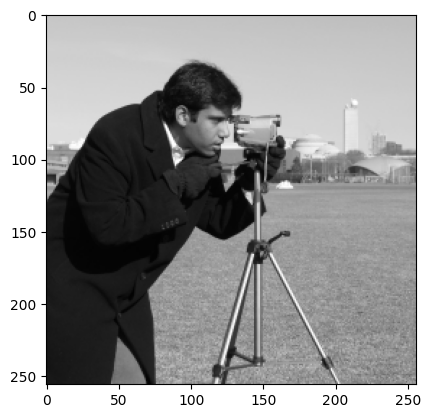

In [10]:
import os
import cv2
from skimage import data

os.makedirs('images', exist_ok=True)
cameraman = cv2.resize(data.camera(), (256, 256), interpolation=cv2.INTER_AREA)
cv2.imwrite('images/cameraman.png', cameraman)

img = cv2.imread('images/cameraman.png')

#Load the image data into a NumPy array
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

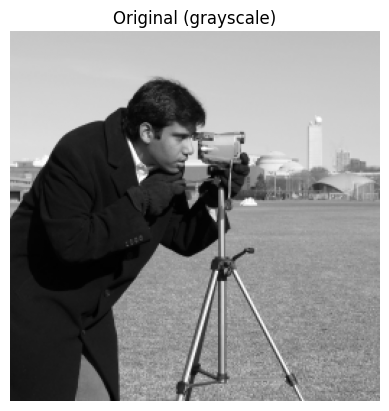

In [14]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap='gray')
plt.title("Original (grayscale)")
plt.axis('off')
plt.show()

####  Scale (increase size)


In [43]:
height, width = img_gray.shape[:2]
print(f"Original size: {width} x {height} pixels")


scale_x = 2
scale_y = 2

Original size: 256 x 256 pixels


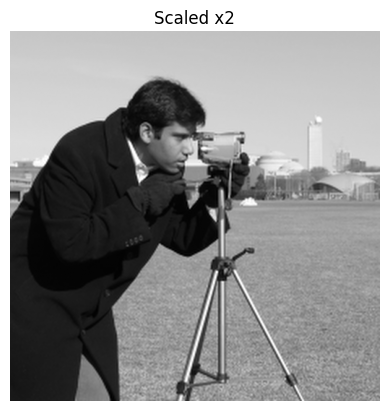

In [44]:
new_size = (width * scale_x, height * scale_y)
scaled_img = cv2.resize(img_gray, new_size, interpolation=cv2.INTER_LANCZOS4)

plt.imshow(scaled_img, cmap='gray')
plt.title("Scaled x2")
plt.axis('off')
plt.show()

In [15]:
cv2.imwrite("images/task1_1_scaled.jpg", scaled_img)
print(f"Original size: {width} x {height}")
print(f"Scaled size:   {scaled_img.shape[1]} x {scaled_img.shape[0]}")

Original size: 256 x 256
Scaled size:   512 x 512


In [16]:
cx, cy = 2, 1
nonuniform_size = (int(width * cx), int(height * cy))

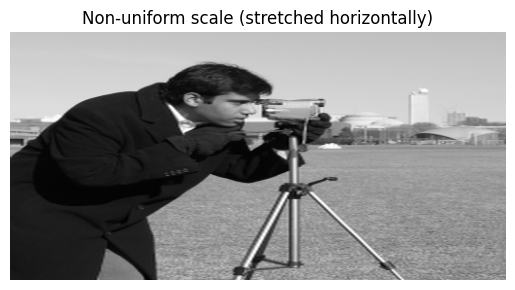

In [17]:
stretched_img = cv2.resize(img_gray, nonuniform_size, interpolation=cv2.INTER_LANCZOS4)

plt.imshow(stretched_img, cmap='gray')
plt.title("Non-uniform scale (stretched horizontally)")
plt.axis('off')
plt.show()

In [18]:
cv2.imwrite("images/task1_1b_stretched.jpg", stretched_img)
print(f"Original size:           {width} x {height}")
print(f"Non-uniform scaled size: {stretched_img.shape[1]} x {stretched_img.shape[0]}")

Original size:           256 x 256
Non-uniform scaled size: 512 x 256


####  Rotate 120°


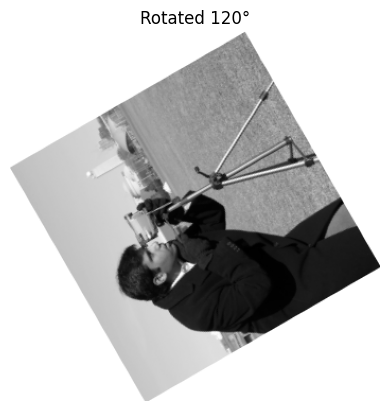

In [21]:
angle = 120
center = (width // 2, height // 2)


M = cv2.getRotationMatrix2D(center, angle, 1.0)


cos = np.abs(M[0, 0])
sin = np.abs(M[0, 1])
new_w = int((height * sin) + (width * cos))
new_h = int((height * cos) + (width * sin))

M[0, 2] += (new_w / 2) - center[0]
M[1, 2] += (new_h / 2) - center[1]

rotated_img = cv2.warpAffine(img_gray, M, (new_w, new_h), borderValue=255)

plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 120°")
plt.axis('off')
plt.show()

In [22]:
cv2.imwrite("images/task1_2_rotated.jpg", rotated_img)
print(f"Original size: {width} x {height}")
print(f"Rotated size:  {rotated_img.shape[1]} x {rotated_img.shape[0]}")

Original size: 256 x 256
Rotated size:  349 x 349


#### Shear

In [23]:
height, width = img_gray.shape[:2]
print(f"Image dimensions: {width} x {height} pixels")

Image dimensions: 256 x 256 pixels


In [28]:
shear_factor = 0.5

shx = shear_factor
shy = 0

new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

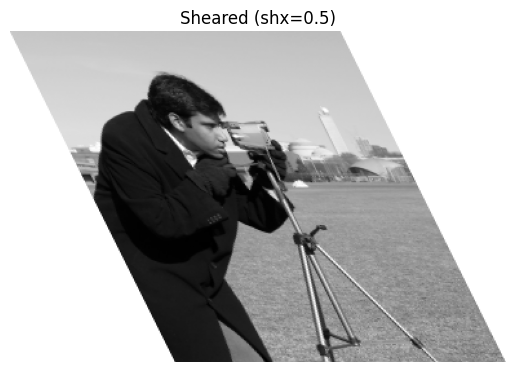

In [29]:
M_shear = np.float32([
    [1,   shx, 0],
    [shy, 1,   0]
])

sheared_img = cv2.warpAffine(img_gray, M_shear, (new_width, new_height), borderValue=255)

plt.imshow(sheared_img, cmap='gray')
plt.title(f"Sheared (shx={shx})")
plt.axis('off')
plt.show()

In [32]:
cv2.imwrite("images/task1_3_sheared.jpg", sheared_img)
print(f"Original size: {width} x {height}")
print(f"Sheared size:  {sheared_img.shape[1]} x {sheared_img.shape[0]}")

Original size: 256 x 256
Sheared size:  384 x 256


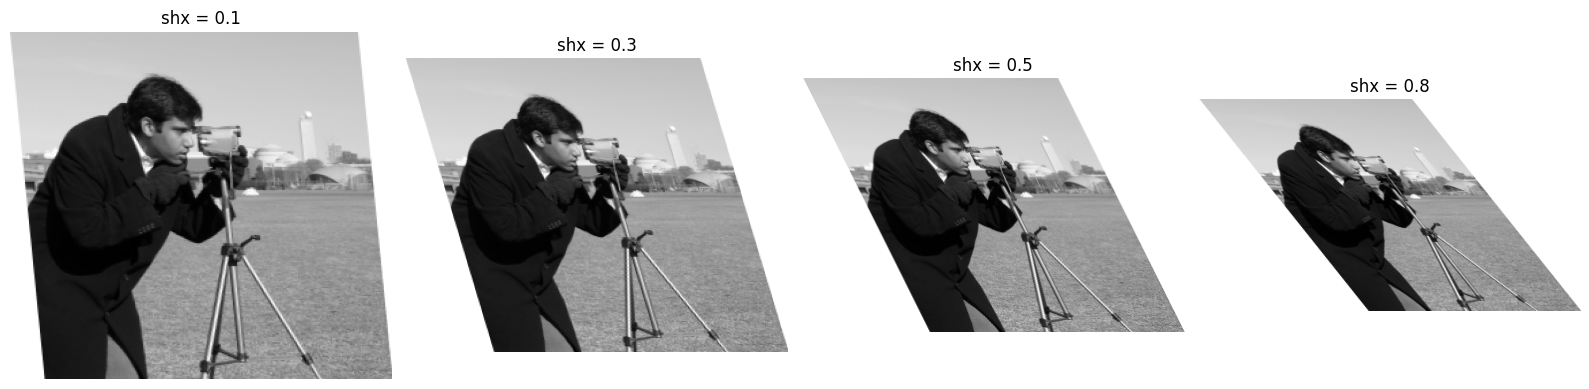

In [38]:

shear_factors = [0.1, 0.3, 0.5, 0.8]

fig, axes = plt.subplots(1, len(shear_factors), figsize=(4 * len(shear_factors), 4))
for ax, sf in zip(axes, shear_factors):
    new_w = int(width + abs(sf) * height)
    M = np.float32([
        [1,  sf, 0],
        [0,  1,  0]
    ])
    result = cv2.warpAffine(img_gray, M, (new_w, height), borderValue=255)
    ax.imshow(result, cmap='gray')
    ax.set_title(f"shx = {sf}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("images/task1_3_shear_factor_comparison.jpg")
plt.show()

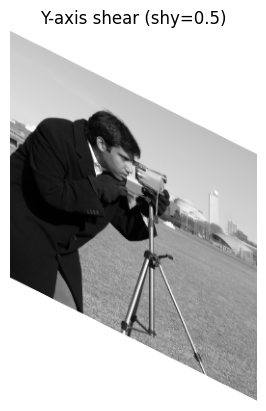

True

In [41]:

shear_factor = 0.5

shx = 0
shy = shear_factor

new_width_y  = width
new_height_y = int(height + abs(shy) * width)

M_yshear = np.float32([
    [1,   shx, 0],
    [shy, 1,   0]
])

y_sheared_img = cv2.warpAffine(img_gray, M_yshear, (new_width_y, new_height_y), borderValue=255)

plt.imshow(y_sheared_img, cmap='gray')
plt.title(f"Y-axis shear (shy={shy})")
plt.axis('off')
plt.show()

cv2.imwrite("images/task1_3b_y_sheared.jpg", y_sheared_img)

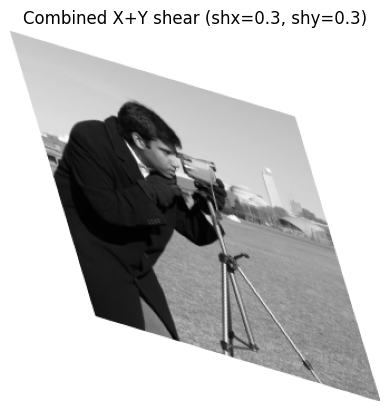

True

In [42]:

shx_combined = 0.3
shy_combined = 0.3

new_width_combined  = int(width  + abs(shx_combined) * height)
new_height_combined = int(height + abs(shy_combined) * width)

M_combined = np.float32([
    [1,             shx_combined, 0],
    [shy_combined,  1,            0]
])

combined_sheared_img = cv2.warpAffine(
    img_gray, M_combined,
    (new_width_combined, new_height_combined),
    borderValue=255
)

plt.imshow(combined_sheared_img, cmap='gray')
plt.title(f"Combined X+Y shear (shx={shx_combined}, shy={shy_combined})")
plt.axis('off')
plt.show()

cv2.imwrite("images/task1_3c_combined_sheared.jpg", combined_sheared_img)

###  Intensity Transformations


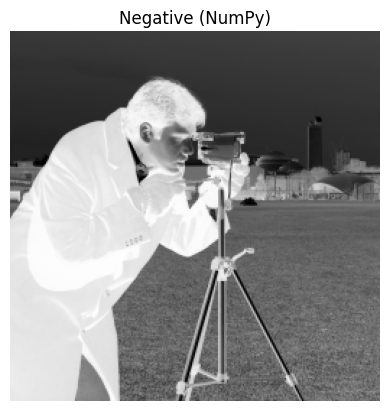

In [33]:
negative_np = 255 - img_gray
cv2.imwrite("images/task2_1_negative_numpy.jpg", negative_np)

plt.imshow(negative_np, cmap='gray')
plt.title("Negative (NumPy)")
plt.axis('off')
plt.show()

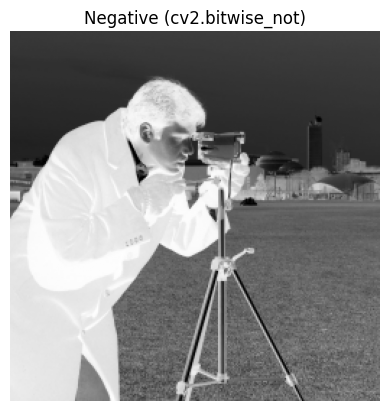

In [34]:
negative_cv = cv2.bitwise_not(img_gray)
cv2.imwrite("images/task2_1_negative_bitwise.jpg", negative_cv)

plt.imshow(negative_cv, cmap='gray')
plt.title("Negative (cv2.bitwise_not)")
plt.axis('off')
plt.show()

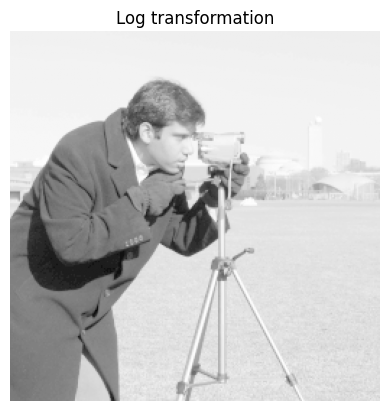

In [35]:
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
img_float = img_gray.astype(np.float64)
log_array = c * np.log(1 + img_float)
log_img = np.clip(log_array, 0, 255).astype(np.uint8)

cv2.imwrite("images/task2_2_log_transform.jpg", log_img)

plt.imshow(log_img, cmap='gray')
plt.title("Log transformation")
plt.axis('off')
plt.show()

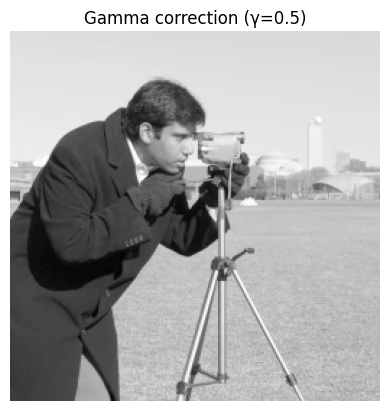

In [36]:
gamma = 0.5
img_norm = img_gray.astype(np.float64) / 255.0
gamma_array = np.power(img_norm, gamma) * 255.0
gamma_img = np.clip(gamma_array, 0, 255).astype(np.uint8)

cv2.imwrite("images/task2_3_gamma_correction.jpg", gamma_img)

plt.imshow(gamma_img, cmap='gray')
plt.title(f"Gamma correction (γ={gamma})")
plt.axis('off')
plt.show()

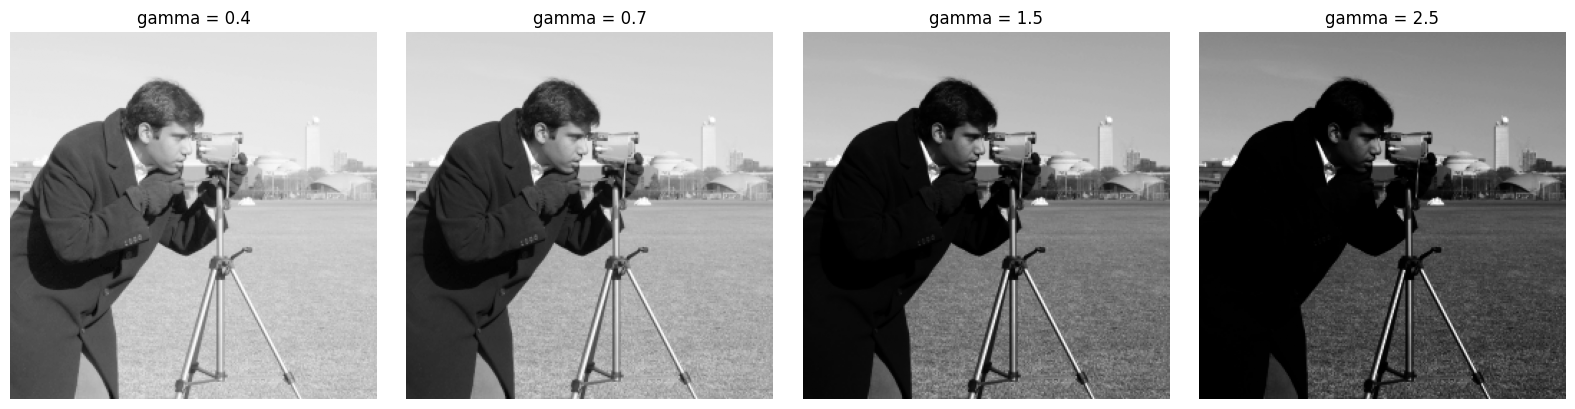

In [37]:
gammas = [0.4, 0.7, 1.5, 2.5]
img_norm = img_gray.astype(np.float64) / 255.0

fig, axes = plt.subplots(1, len(gammas), figsize=(4 * len(gammas), 4))
for ax, g in zip(axes, gammas):
    result = np.clip(np.power(img_norm, g) * 255.0, 0, 255).astype(np.uint8)
    ax.imshow(result, cmap='gray')
    ax.set_title(f"gamma = {g}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("images/task2_3_gamma_comparison.jpg")
plt.show()